# Classification multimodale image + texte

Ce notebook combine les modèles unimodaux image et texte précédemment entraînés. L'objectif est d'évaluer si la fusion des deux modalités améliore la classification multi-label par rapport aux approches image seule et texte seule.

Le notebook multimodal ne réentraîne pas les modèles image et texte depuis zéro. Il les recharge depuis le registre des modèles, prépare les entrées synchronisées, puis compare plusieurs stratégies de fusion.


## 1. Objectif du notebook

- Combiner deux modalités : image et texte.
- Réutiliser le meilleur modèle image entraîné dans `image_classifier.ipynb`.
- Réutiliser le meilleur modèle texte entraîné dans `text_classiffier.ipynb`.
- Comparer les performances unimodales et multimodales.
- Sélectionner et sauvegarder le meilleur modèle multimodal.


## 2. Initialisation de l'environnement et r?cup?ration des artefacts unimodaux

Cette partie pr?pare l'environnement du notebook multimodal et r?cup?re les chemins r?ellement sauvegard?s dans le registre des mod?les.

La fusion multimodale doit r?utiliser les sorties des notebooks pr?c?dents :

- le dataset annot? `train.csv`,
- le dossier des images,
- les m?tadonn?es du mod?le image,
- les m?tadonn?es du mod?le texte,
- le mod?le image sauvegard?,
- le mod?le texte sauvegard?, qui peut ?tre un mod?le Keras ou un mod?le `sklearn`,
- le preprocessing texte associ? : tokenizer ou vectorizer TF-IDF,
- le futur chemin de sauvegarde du mod?le multimodal.

Cette ?tape ?vite de supposer un format de mod?le texte fixe. Dans ce projet, le meilleur mod?le texte peut ?tre un mod?le classique comme `Logistic Regression`, sauvegard? en `.joblib`, et non forc?ment un mod?le `.keras`.


In [15]:
import json
import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import classification_report

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import importlib
import common
from utils import utils_classifier_image as image_utils
from utils import utils_classifier_text as text_utils

importlib.reload(common)
importlib.reload(image_utils)
importlib.reload(text_utils)

TRAIN_CSV_PATH = common.TRAIN_CSV_PATH
IMAGE_DIR = common.IMAGE_DIR
REGISTRY_DIR = common.REGISTRY_DIR

IMAGE_METADATA_PATH = REGISTRY_DIR / "image_model_metadata.json"
TEXT_METADATA_PATH = REGISTRY_DIR / "text_model_metadata.json"
MULTIMODAL_METADATA_PATH = REGISTRY_DIR / "multimodal_model_metadata.json"
MULTIMODAL_MODEL_PATH = common.MULTIMODAL_MODEL_PATH

image_metadata = {}
text_metadata = {}

if IMAGE_METADATA_PATH.exists():
    image_metadata = json.loads(IMAGE_METADATA_PATH.read_text(encoding="utf-8"))

if TEXT_METADATA_PATH.exists():
    text_metadata = json.loads(TEXT_METADATA_PATH.read_text(encoding="utf-8"))

IMAGE_MODEL_PATH = Path(image_metadata.get("model_path", common.IMAGE_MODEL_PATH))
TEXT_MODEL_TYPE = text_metadata.get("model_type", "unknown")
TEXT_MODEL_PATH = Path(text_metadata.get("model_path", common.TEXT_MODEL_PATH))

TEXT_TOKENIZER_PATH = None
if text_metadata.get("tokenizer_path"):
    TEXT_TOKENIZER_PATH = Path(text_metadata["tokenizer_path"])

TEXT_TFIDF_VECTORIZER_PATH = None
if text_metadata.get("tfidf_vectorizer_path"):
    TEXT_TFIDF_VECTORIZER_PATH = Path(text_metadata["tfidf_vectorizer_path"])

IMG_SIZE = tuple(image_metadata.get("image_size", common.IMG_SIZE))
BATCH_SIZE = image_metadata.get("batch_size", common.BATCH_SIZE)
RANDOM_STATE = common.RANDOM_STATE
AUTOTUNE = tf.data.AUTOTUNE

artifact_rows = [
    {
        "name": "train.csv",
        "type": "dataset",
        "path": TRAIN_CSV_PATH,
        "exists": TRAIN_CSV_PATH.exists(),
    },
    {
        "name": "image_dir",
        "type": "images",
        "path": IMAGE_DIR,
        "exists": IMAGE_DIR.exists(),
    },
    {
        "name": "image_metadata",
        "type": "metadata",
        "path": IMAGE_METADATA_PATH,
        "exists": IMAGE_METADATA_PATH.exists(),
    },
    {
        "name": "text_metadata",
        "type": "metadata",
        "path": TEXT_METADATA_PATH,
        "exists": TEXT_METADATA_PATH.exists(),
    },
    {
        "name": image_metadata.get("model_name", "image_model"),
        "type": "image_model",
        "path": IMAGE_MODEL_PATH,
        "exists": IMAGE_MODEL_PATH.exists(),
    },
    {
        "name": text_metadata.get("model_name", "text_model"),
        "type": f"text_model_{TEXT_MODEL_TYPE}",
        "path": TEXT_MODEL_PATH,
        "exists": TEXT_MODEL_PATH.exists(),
    },
    {
        "name": "text_tokenizer",
        "type": "text_preprocessing",
        "path": TEXT_TOKENIZER_PATH,
        "exists": TEXT_TOKENIZER_PATH.exists() if TEXT_TOKENIZER_PATH else False,
    },
    {
        "name": "text_tfidf_vectorizer",
        "type": "text_preprocessing",
        "path": TEXT_TFIDF_VECTORIZER_PATH,
        "exists": TEXT_TFIDF_VECTORIZER_PATH.exists() if TEXT_TFIDF_VECTORIZER_PATH else False,
    },
    {
        "name": "multimodal_model_output",
        "type": "output",
        "path": MULTIMODAL_MODEL_PATH,
        "exists": MULTIMODAL_MODEL_PATH.exists(),
    },
]

artifact_status_df = pd.DataFrame(artifact_rows)
artifact_status_df["path"] = artifact_status_df["path"].astype(str)

display(artifact_status_df)

print("Racine du projet :", PROJECT_ROOT)
print("Type du mod?le texte retenu :", TEXT_MODEL_TYPE)
print("Mod?le image retenu :", image_metadata.get("model_name", "non d?fini"))
print("Mod?le texte retenu :", text_metadata.get("model_name", "non d?fini"))
print("Taille image :", IMG_SIZE)
print("Batch size :", BATCH_SIZE)
print("Random state :", RANDOM_STATE)


,name,type,path,exists
0,train.csv,dataset,C:\Users\mupps\Documents\Tp_bihar-2025-2026\tr...,True
1,image_dir,images,C:\Users\mupps\Desktop\COMP5329S1A2Dataset\data,True
2,image_metadata,metadata,C:\Users\mupps\Documents\Tp_bihar-2025-2026\mo...,True
3,text_metadata,metadata,C:\Users\mupps\Documents\Tp_bihar-2025-2026\mo...,True
4,ResNet50 fine-tuning,image_model,C:\Users\mupps\Documents\Tp_bihar-2025-2026\mo...,True
5,Logistic Regression,text_model_sklearn,C:\Users\mupps\Documents\Tp_bihar-2025-2026\mo...,True
6,text_tokenizer,text_preprocessing,None,False
7,text_tfidf_vectorizer,text_preprocessing,C:\Users\mupps\Documents\Tp_bihar-2025-2026\mo...,True
8,multimodal_model_output,output,C:\Users\mupps\Documents\Tp_bihar-2025-2026\mo...,False


Racine du projet : c:\Users\mupps\Documents\Tp_bihar-2025-2026
Type du mod?le texte retenu : sklearn
Mod?le image retenu : ResNet50 fine-tuning
Mod?le texte retenu : Logistic Regression
Taille image : (224, 224)
Batch size : 32
Random state : 42


## Note - Initialisation de l'environnement et r?cup?ration des artefacts unimodaux

Cette ?tape pr?pare l'environnement de travail du notebook multimodal. On ajoute la racine du projet au `sys.path` pour pouvoir importer `common.py` et les fonctions utilitaires d?j? cr??es pour les mod?les image et texte. Les chemins importants sont ensuite r?cup?r?s depuis `common.py` et depuis les fichiers de m?tadonn?es sauvegard?s dans `model/registry`.

L'objectif n'est pas encore de charger les mod?les en m?moire, mais de v?rifier quels artefacts sont disponibles : mod?le image, mod?le texte, vectoriseur TF-IDF ou tokenizer selon le type de mod?le texte retenu, ainsi que le futur chemin du mod?le multimodal. Cette v?rification est importante car le meilleur mod?le texte enregistr? peut ?tre un mod?le `sklearn` sauvegard? avec `joblib`, alors que le mod?le image est un mod?le Keras. La suite du notebook pourra donc adapter le chargement en fonction du type r?el de mod?le.



## 3. Chargement du dataset commun

Cette partie doit charger le fichier annoté `train.csv` et conserver les colonnes utiles :

- `ImageID`,
- `Caption`,
- `Labels`.

Les champs doivent être nettoyés de façon minimale : espaces inutiles, captions vides, labels vides et vérification de l'existence des images associées.


In [16]:
def load_multimodal_csv(csv_path):
    """
    Charge le fichier train.csv du dataset multimodal.

    Le fichier contient trois informations utiles : ImageID, Labels et Caption.
    Certaines captions peuvent contenir des virgules, donc on s?pare uniquement
    les deux premi?res colonnes et on conserve le reste comme texte descriptif.
    """
    rows = []
    skipped_rows = []

    with open(csv_path, "r", encoding="utf-8") as file:
        header = next(file, None)

        for line_number, line in enumerate(file, start=2):
            line = line.rstrip("\n")

            if not line.strip():
                continue

            parts = line.split(",", 2)

            if len(parts) != 3:
                skipped_rows.append({"line": line_number, "content": line})
                continue

            image_id, labels, caption = parts
            caption = caption.strip()

            if caption.startswith('"') and caption.endswith('"'):
                caption = caption[1:-1]

            caption = caption.replace('""', '"')

            rows.append({
                "ImageID": image_id.strip(),
                "Labels": labels.strip(),
                "Caption": caption.strip(),
            })

    return pd.DataFrame(rows), skipped_rows


multimodal_df, skipped_rows = load_multimodal_csv(TRAIN_CSV_PATH)

multimodal_df["Labels_list"] = multimodal_df["Labels"].apply(text_utils.parse_labels)
multimodal_df["caption_word_count"] = multimodal_df["Caption"].str.split().str.len()
multimodal_df["image_path"] = multimodal_df["ImageID"].apply(lambda image_id: IMAGE_DIR / image_id)
multimodal_df["image_exists"] = multimodal_df["image_path"].apply(lambda path: path.exists())

missing_image_df = multimodal_df.loc[~multimodal_df["image_exists"], ["ImageID", "image_path"]]
missing_caption_count = multimodal_df["Caption"].isna().sum() + (multimodal_df["Caption"].str.strip() == "").sum()
duplicate_image_count = multimodal_df["ImageID"].duplicated().sum()

observed_labels = sorted({label for labels in multimodal_df["Labels_list"] for label in labels})
metadata_labels = image_metadata.get("classes") or text_metadata.get("classes") or []
expected_labels = sorted([int(label) for label in metadata_labels]) if metadata_labels else observed_labels

print("Nombre de lignes charg?es :", len(multimodal_df))
print("Lignes ignor?es pendant le chargement :", len(skipped_rows))
print("Captions manquantes :", missing_caption_count)
print("ImageID dupliqu?s :", duplicate_image_count)
print("Images introuvables :", len(missing_image_df))
print("Labels observ?s :", observed_labels)
print("Labels attendus :", expected_labels)

if len(missing_image_df) > 0:
    display(missing_image_df.head())

# On conserve uniquement les exemples exploitables par les deux modalit?s.
multimodal_df = multimodal_df.loc[
    multimodal_df["image_exists"] & multimodal_df["Caption"].notna() & (multimodal_df["Caption"].str.strip() != "")
].reset_index(drop=True)

print("Nombre d'exemples conserv?s pour le multimodal :", len(multimodal_df))

display(multimodal_df[["ImageID", "Caption", "Labels", "Labels_list", "caption_word_count", "image_exists"]].head())



Nombre de lignes charg?es : 30000
Lignes ignor?es pendant le chargement : 4
Captions manquantes : 0
ImageID dupliqu?s : 0
Images introuvables : 0
Labels observ?s : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19]
Labels attendus : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19]
Nombre d'exemples conserv?s pour le multimodal : 30000


,ImageID,Caption,Labels,Labels_list,caption_word_count,image_exists
0,0.jpg,Woman in swim suit holding parasol on sunny day.,1,[1],9,True
1,1.jpg,A couple of men riding horses on top of a gree...,1 19,"[1, 19]",12,True
2,2.jpg,They are brave for riding in the jungle on tho...,1,[1],11,True
3,3.jpg,a black and silver clock tower at an intersect...,8 3 13,"[8, 3, 13]",12,True
4,4.jpg,A train coming to a stop on the tracks out side.,8 3 7,"[8, 3, 7]",11,True


## Note - Chargement du dataset commun

Cette ?tape construit la base commune utilis?e par la classification multimodale. Contrairement aux notebooks unimodaux, on doit conserver simultan?ment les informations n?cessaires ? l'image et au texte : l'identifiant de l'image, la caption et les labels multi-label. Le fichier `train.csv` est charg? de mani?re robuste afin d'?viter les erreurs de parsing li?es aux virgules pr?sentes dans certaines descriptions textuelles.

Les labels sont transform?s en listes d'entiers dans `Labels_list`, ce qui permettra ensuite de les encoder avec `MultiLabelBinarizer`. Le chemin complet des images est ajout? dans `image_path`, mais il sert uniquement au chargement des fichiers image, pas comme variable explicative du mod?le. La colonne `image_exists` permet de v?rifier que chaque exemple poss?de bien les deux modalit?s n?cessaires. ? la fin de cette ?tape, `multimodal_df` contient donc uniquement les exemples exploitables pour une fusion image + texte.



## 4. Split commun train / validation / test

Le split doit rester identique entre les notebooks image, texte et multimodal :

- 70% train,
- 15% validation,
- 15% test.

Le même `random_state` doit être utilisé afin de garder les instances synchronisées entre les images, les captions et les labels.


In [17]:
multimodal_df = multimodal_df.copy()
multimodal_df["source_index"] = np.arange(len(multimodal_df))

train_df, temp_df = train_test_split(
    multimodal_df,
    test_size=0.30,
    random_state=RANDOM_STATE,
    shuffle=True,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_STATE,
    shuffle=True,
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

split_summary_df = pd.DataFrame({
    "split": ["train", "validation", "test", "total"],
    "rows": [len(train_df), len(val_df), len(test_df), len(multimodal_df)],
})

split_summary_df["proportion"] = (
    split_summary_df["rows"] / len(multimodal_df)
).round(3)

print("Train :", train_df.shape)
print("Validation :", val_df.shape)
print("Test :", test_df.shape)
print("Proportion train :", round(len(train_df) / len(multimodal_df), 3))
print("Proportion validation :", round(len(val_df) / len(multimodal_df), 3))
print("Proportion test :", round(len(test_df) / len(multimodal_df), 3))

# V?rification : chaque ImageID doit appara?tre dans un seul split.
train_ids = set(train_df["ImageID"])
val_ids = set(val_df["ImageID"])
test_ids = set(test_df["ImageID"])

print("Intersection train / validation :", len(train_ids & val_ids))
print("Intersection train / test :", len(train_ids & test_ids))
print("Intersection validation / test :", len(val_ids & test_ids))

display(split_summary_df)
display(train_df[["ImageID", "Caption", "Labels", "Labels_list"]].head())



Train : (21000, 8)
Validation : (4500, 8)
Test : (4500, 8)
Proportion train : 0.7
Proportion validation : 0.15
Proportion test : 0.15
Intersection train / validation : 0
Intersection train / test : 0
Intersection validation / test : 0


,split,rows,proportion
0,train,21000,0.70
1,validation,4500,0.15
2,test,4500,0.15
3,total,30000,1.00


,ImageID,Caption,Labels,Labels_list
0,28465.jpg,A person sitting on the sidewalk holding an um...,1 3,"[1, 3]"
1,27622.jpg,A dark colored airplane sitting on a tarmac,5,[5]
2,28376.jpg,A stuffed bear is posed looking out over the w...,9,[9]
3,10917.jpg,A baeball player I l9e standing in a field,1,[1]
4,27234.jpg,A woman flying a kite while standing on a beach.,1,[1]


## Note - Split commun train / validation / test

Cette ?tape s?pare le dataset multimodal en trois ensembles : entra?nement, validation et test. La s?paration est faite une seule fois sur `multimodal_df`, afin de garantir que les images, les textes et les labels restent parfaitement align?s. On ?vite donc de cr?er un split s?par? pour les images et un autre pour les textes, car cela pourrait m?langer les instances et cr?er une fuite ou une incoh?rence entre les modalit?s.

La r?partition retenue suit le cahier des charges : environ 70% des donn?es pour l'entra?nement, 15% pour la validation et 15% pour le test. Le `random_state` rend cette s?paration reproductible. Les intersections entre les `ImageID` des trois ensembles sont v?rifi?es pour confirmer qu'un m?me exemple n'appara?t pas dans plusieurs splits.

La stratification n'est pas appliqu?e directement ici, car le probl?me est multi-label : une m?me image peut appartenir ? plusieurs classes. La distribution des labels sera contr?l?e dans l'?tape suivante apr?s l'encodage multi-label.



## 5. Encodage des labels multi-label

Les labels constituent la cible supervisée commune aux trois approches :

- image seule,
- texte seul,
- image + texte.

Cette partie doit transformer les labels en vecteurs binaires multi-label à l'aide d'un `MultiLabelBinarizer`, chargé depuis le registre si disponible, ou reconstruit avec les mêmes classes que les notebooks unimodaux.


Classes : [ 1  2  3  4  5  6  7  8  9 10 11 13 14 15 16 17 18 19]
Nombre de classes : 18
y_train shape : (21000, 18)
y_val shape : (4500, 18)
y_test shape : (4500, 18)
Labels attendus : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19]
Labels encod?s : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19]
Labels manquants : []
Labels inattendus : []


,label,count,frequency_percent
0,1,15935,75.88
1,2,825,3.93
2,3,3055,14.55
3,4,872,4.15
4,5,757,3.60
5,6,982,4.68
6,7,857,4.08
7,8,1527,7.27
8,9,730,3.48
9,10,1013,4.82


,label,count,frequency_percent
0,1,3459,76.87
1,2,169,3.76
2,3,626,13.91
3,4,185,4.11
4,5,173,3.84
5,6,200,4.44
6,7,182,4.04
7,8,330,7.33
8,9,156,3.47
9,10,216,4.80


,label,count,frequency_percent
0,1,3403,75.62
1,2,170,3.78
2,3,684,15.20
3,4,215,4.78
4,5,202,4.49
5,6,213,4.73
6,7,182,4.04
7,8,353,7.84
8,9,156,3.47
9,10,242,5.38


,label,train,validation,test
0,1,15935,3459,3403
1,2,825,169,170
2,3,3055,626,684
3,4,872,185,215
4,5,757,173,202
5,6,982,200,213
6,7,857,182,182
7,8,1527,330,353
8,9,730,156,156
9,10,1013,216,242


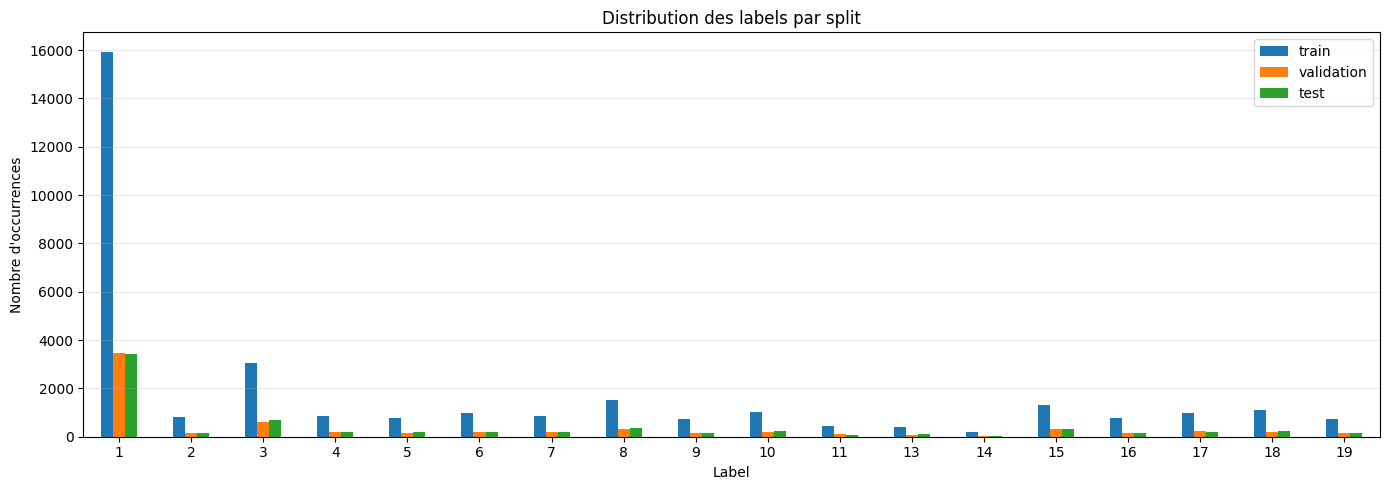

In [18]:
mlb = MultiLabelBinarizer(classes=expected_labels)
mlb.fit(train_df["Labels_list"])

y_train = mlb.transform(train_df["Labels_list"])
y_val = mlb.transform(val_df["Labels_list"])
y_test = mlb.transform(test_df["Labels_list"])

classes = mlb.classes_
class_names = [f"Label {label}" for label in classes]
NUM_CLASSES = len(classes)

train_label_distribution = text_utils.label_distribution_from_binary(y_train, classes)
val_label_distribution = text_utils.label_distribution_from_binary(y_val, classes)
test_label_distribution = text_utils.label_distribution_from_binary(y_test, classes)

label_distribution_by_split = pd.DataFrame({
    "label": classes,
    "train": y_train.sum(axis=0),
    "validation": y_val.sum(axis=0),
    "test": y_test.sum(axis=0),
})

labels_in_splits = sorted({
    label
    for labels in pd.concat([
        train_df["Labels_list"],
        val_df["Labels_list"],
        test_df["Labels_list"],
    ])
    for label in labels
})

missing_labels = sorted(set(expected_labels) - set(labels_in_splits))
unexpected_labels = sorted(set(labels_in_splits) - set(expected_labels))

print("Classes :", classes)
print("Nombre de classes :", NUM_CLASSES)
print("y_train shape :", y_train.shape)
print("y_val shape :", y_val.shape)
print("y_test shape :", y_test.shape)
print("Labels attendus :", expected_labels)
print("Labels encod?s :", labels_in_splits)
print("Labels manquants :", missing_labels)
print("Labels inattendus :", unexpected_labels)

display(train_label_distribution)
display(val_label_distribution)
display(test_label_distribution)
display(label_distribution_by_split)

ax = label_distribution_by_split.plot(
    x="label",
    y=["train", "validation", "test"],
    kind="bar",
    figsize=(14, 5),
)
ax.set_title("Distribution des labels par split")
ax.set_xlabel("Label")
ax.set_ylabel("Nombre d'occurrences")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



## Note - Encodage des labels multi-label

Cette ?tape transforme les labels textuels du fichier CSV en matrices binaires utilisables par les mod?les. Comme le probl?me est multi-label, une m?me ligne peut contenir plusieurs classes. `MultiLabelBinarizer` cr?e donc une colonne par label possible : une valeur `1` indique que le label est pr?sent pour l'exemple, et une valeur `0` indique qu'il est absent.

Les variables `y_train`, `y_val` et `y_test` correspondent aux cibles des trois splits cr??s pr?c?demment. Elles seront utilis?es ? la fois pour ?valuer les mod?les unimodaux sauvegard?s et pour entra?ner ou comparer les approches de fusion multimodale.

La distribution des labels est affich?e pour v?rifier que les trois splits restent coh?rents. On observe g?n?ralement un fort d?s?quilibre, notamment avec le label 1 beaucoup plus fr?quent que les autres. Ce point devra ?tre pris en compte dans l'interpr?tation des m?triques : l'accuracy seule n'est pas suffisante, et il faut privil?gier des mesures comme la F1-score, l'Average Precision ou l'AUC.



## 6. Chargement des modèles unimodaux sauvegardés

Cette partie doit charger les artefacts produits par les notebooks unimodaux :

- modèle image sauvegardé,
- modèle texte sauvegardé,
- tokenizer ou vectorizer texte,
- encodeur des labels.

Il faut également vérifier les formats d'entrée attendus par chaque modèle : taille des images, longueur maximale des séquences texte et nombre de labels en sortie.


In [19]:
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet50_preprocess_input


def load_required_artifact(path, artifact_name):
    """V?rifie qu'un artefact existe avant son chargement."""
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"{artifact_name} introuvable : {path}")

    return path


keras_custom_objects = {
    "preprocess_input": resnet50_preprocess_input,
}

IMAGE_MODEL_PATH = load_required_artifact(IMAGE_MODEL_PATH, "Mod?le image")
image_model = tf.keras.models.load_model(
    IMAGE_MODEL_PATH,
    custom_objects=keras_custom_objects,
    compile=False,
    safe_mode=False,
)

text_model = None
text_vectorizer = None
text_tokenizer = None

if TEXT_MODEL_TYPE == "sklearn":
    TEXT_MODEL_PATH = load_required_artifact(TEXT_MODEL_PATH, "Mod?le texte sklearn")
    text_model = joblib.load(TEXT_MODEL_PATH)

    if TEXT_TFIDF_VECTORIZER_PATH is None:
        raise ValueError("Le mod?le texte sklearn n?cessite un vectoriseur TF-IDF sauvegard?.")

    TEXT_TFIDF_VECTORIZER_PATH = load_required_artifact(
        TEXT_TFIDF_VECTORIZER_PATH,
        "Vectoriseur TF-IDF",
    )
    text_vectorizer = joblib.load(TEXT_TFIDF_VECTORIZER_PATH)

elif TEXT_MODEL_TYPE == "keras":
    TEXT_MODEL_PATH = load_required_artifact(TEXT_MODEL_PATH, "Mod?le texte Keras")
    text_model = tf.keras.models.load_model(
        TEXT_MODEL_PATH,
        custom_objects=keras_custom_objects,
        compile=False,
        safe_mode=False,
    )

    if TEXT_TOKENIZER_PATH is not None:
        TEXT_TOKENIZER_PATH = load_required_artifact(TEXT_TOKENIZER_PATH, "Tokenizer texte")
        text_tokenizer = joblib.load(TEXT_TOKENIZER_PATH)

else:
    raise ValueError(f"Type de mod?le texte non reconnu : {TEXT_MODEL_TYPE}")

loaded_artifacts_df = pd.DataFrame([
    {
        "artifact": "image_model",
        "type": "keras",
        "path": str(IMAGE_MODEL_PATH),
        "loaded": image_model is not None,
    },
    {
        "artifact": "text_model",
        "type": TEXT_MODEL_TYPE,
        "path": str(TEXT_MODEL_PATH),
        "loaded": text_model is not None,
    },
    {
        "artifact": "text_vectorizer",
        "type": "tfidf" if text_vectorizer is not None else None,
        "path": str(TEXT_TFIDF_VECTORIZER_PATH) if TEXT_TFIDF_VECTORIZER_PATH else None,
        "loaded": text_vectorizer is not None,
    },
    {
        "artifact": "text_tokenizer",
        "type": "tokenizer" if text_tokenizer is not None else None,
        "path": str(TEXT_TOKENIZER_PATH) if TEXT_TOKENIZER_PATH else None,
        "loaded": text_tokenizer is not None,
    },
])

print("Mod?le image charg? :", image_metadata.get("model_name", IMAGE_MODEL_PATH.name))
print("Type du mod?le texte charg? :", TEXT_MODEL_TYPE)
print("Mod?le texte charg? :", text_metadata.get("model_name", TEXT_MODEL_PATH.name))

display(loaded_artifacts_df)

print("R?sum? du mod?le image :")
image_model.summary()

if TEXT_MODEL_TYPE == "keras":
    print("R?sum? du mod?le texte Keras :")
    text_model.summary()
else:
    print("Mod?le texte sklearn :", type(text_model).__name__)
    print("Pr?processeur texte :", type(text_vectorizer).__name__)



Mod?le image charg? : ResNet50 fine-tuning
Type du mod?le texte charg? : sklearn
Mod?le texte charg? : Logistic Regression


,artifact,type,path,loaded
0,image_model,keras,C:\Users\mupps\Documents\Tp_bihar-2025-2026\mo...,True
1,text_model,sklearn,C:\Users\mupps\Documents\Tp_bihar-2025-2026\mo...,True
2,text_vectorizer,tfidf,C:\Users\mupps\Documents\Tp_bihar-2025-2026\mo...,True
3,text_tokenizer,None,None,False


R?sum? du mod?le image :


Model: "resnet50_feature_extractor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescale_to_255 (Rescaling)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50_preprocessing (Lambda) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ image_features                  │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multi_label_output (Dense)      │ (None, 18)             │         4,626 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,116,882 (92.00 MB)

 Trainable params: 14,957,842 (57.06 MB)

 Non-trainable params: 9,159,040 (34.94 MB)

Mod?le texte sklearn : OneVsRestClassifier
Pr?processeur texte : TfidfVectorizer


## Note - Chargement des mod?les unimodaux sauvegard?s

Cette ?tape charge r?ellement les mod?les entra?n?s dans les notebooks pr?c?dents. Le mod?le image est un mod?le Keras sauvegard?, donc il est charg? avec `tf.keras.models.load_model`. Le mod?le texte est charg? selon son type indiqu? dans les m?tadonn?es : s'il s'agit d'un mod?le `sklearn`, il est charg? avec `joblib`; s'il s'agit d'un mod?le Keras, il est charg? avec TensorFlow.

Le mod?le image contient une couche `Lambda` utilis?e pour appliquer le pr?traitement ResNet50 (`preprocess_input`). Au moment du chargement, cette fonction doit ?tre redonn?e explicitement ? Keras via `custom_objects`. Le param?tre `safe_mode=False` est utilis? ici uniquement pour autoriser la d?s?rialisation de cette couche `Lambda` d?j? cr??e dans notre propre notebook.

Dans l'?tat actuel du projet, le meilleur mod?le texte retenu est un mod?le classique de type Logistic Regression avec un encodage TF-IDF. Il faut donc charger ? la fois le mod?le `sklearn` et son vectoriseur TF-IDF. Ce point est important pour la suite : la branche image et la branche texte n'ont pas forc?ment le m?me format technique, mais elles peuvent toutes les deux produire des probabilit?s par label.

Les mod?les Keras sont charg?s avec `compile=False`, car on les utilise ici principalement pour g?n?rer des pr?dictions ou extraire des repr?sentations. La recompilation n'est pas n?cessaire pour cette ?tape et cela ?vite les erreurs li?es aux m?triques personnalis?es sauvegard?es avec le mod?le.



## 7. Préparation des entrées multimodales

Cette partie doit préparer les entrées synchronisées pour chaque exemple :

- image prétraitée : lecture, redimensionnement et normalisation,
- caption prétraitée : tokenisation et padding,
- labels multi-label encodés.

Le dataset final doit permettre d'alimenter un modèle avec deux entrées : `image` et `text_tokens`.


In [20]:
train_image_paths = train_df["image_path"].astype(str).to_numpy()
val_image_paths = val_df["image_path"].astype(str).to_numpy()
test_image_paths = test_df["image_path"].astype(str).to_numpy()

train_captions = train_df["Caption"].astype(str).to_numpy()
val_captions = val_df["Caption"].astype(str).to_numpy()
test_captions = test_df["Caption"].astype(str).to_numpy()


def load_image_for_multimodal(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image


def build_image_prediction_dataset(image_paths, batch_size=BATCH_SIZE):
    dataset = tf.data.Dataset.from_tensor_slices(image_paths)
    dataset = dataset.map(load_image_for_multimodal, num_parallel_calls=AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(AUTOTUNE)
    return dataset


def build_text_input(captions):
    cleaned_captions = [text_utils.clean_text(caption) for caption in captions]

    if TEXT_MODEL_TYPE == "sklearn":
        if text_vectorizer is None:
            raise ValueError("text_vectorizer est requis pour le mod?le texte sklearn.")
        return text_vectorizer.transform(cleaned_captions)

    if TEXT_MODEL_TYPE == "keras":
        if text_tokenizer is None:
            raise ValueError("text_tokenizer est requis pour le mod?le texte Keras.")

        max_sequence_length = text_metadata.get("max_sequence_length")
        if max_sequence_length is None:
            raise ValueError("max_sequence_length est absent des m?tadonn?es du mod?le texte.")

        sequences = text_tokenizer.texts_to_sequences(cleaned_captions)
        return tf.keras.preprocessing.sequence.pad_sequences(
            sequences,
            maxlen=int(max_sequence_length),
            padding="post",
            truncating="post",
        )

    raise ValueError(f"Type de mod?le texte non reconnu : {TEXT_MODEL_TYPE}")


def predict_text_probabilities(captions):
    text_input = build_text_input(captions)

    if TEXT_MODEL_TYPE == "sklearn":
        if hasattr(text_model, "predict_proba"):
            probabilities = text_model.predict_proba(text_input)

            if isinstance(probabilities, list):
                probabilities = np.column_stack([proba[:, 1] for proba in probabilities])

            return np.asarray(probabilities)

        scores = text_model.decision_function(text_input)
        scores = np.clip(scores, -50, 50)
        return 1 / (1 + np.exp(-scores))

    return text_model.predict(text_input, batch_size=BATCH_SIZE, verbose=1)


train_image_ds = build_image_prediction_dataset(train_image_paths)
val_image_ds = build_image_prediction_dataset(val_image_paths)
test_image_ds = build_image_prediction_dataset(test_image_paths)

multimodal_inputs_summary_df = pd.DataFrame([
    {"split": "train", "rows": len(train_df), "image_paths": len(train_image_paths), "captions": len(train_captions), "targets_shape": y_train.shape},
    {"split": "validation", "rows": len(val_df), "image_paths": len(val_image_paths), "captions": len(val_captions), "targets_shape": y_val.shape},
    {"split": "test", "rows": len(test_df), "image_paths": len(test_image_paths), "captions": len(test_captions), "targets_shape": y_test.shape},
])

print("Taille image utilis?e :", IMG_SIZE)
print("Batch size :", BATCH_SIZE)
print("Type d'entr?e texte :", "TF-IDF" if TEXT_MODEL_TYPE == "sklearn" else "s?quences tokenis?es")

display(multimodal_inputs_summary_df)
display(test_df[["ImageID", "Caption", "Labels_list"]].head())



Taille image utilis?e : (224, 224)
Batch size : 32
Type d'entr?e texte : TF-IDF


,split,rows,image_paths,captions,targets_shape
0,train,21000,21000,21000,"(21000, 18)"
1,validation,4500,4500,4500,"(4500, 18)"
2,test,4500,4500,4500,"(4500, 18)"


,ImageID,Caption,Labels_list
0,25135.jpg,Two people standing on a snowy hill.,[1]
1,6628.jpg,a woman wearing a backpack and holding onto a ...,"[1, 15]"
2,3263.jpg,A woman is preparing to hit a tennis ball with...,[1]
3,23575.jpg,a red double decker bus parked at a bus stop i...,"[1, 10, 6]"
4,2733.jpg,a pair of feet doing a trick on a skate board,[1]


## Note - Pr?paration des entr?es multimodales

Cette ?tape pr?pare les deux modalit?s ? partir des m?mes splits : les chemins d'images pour la branche visuelle et les captions pour la branche textuelle. Les images ne sont pas charg?es toutes en m?moire ; elles sont lues par batch avec `tf.data`, redimensionn?es ? la taille attendue par le mod?le image, puis normalis?es entre 0 et 1.

Pour le texte, le pr?traitement d?pend du mod?le sauvegard?. Comme le mod?le texte retenu est un mod?le `sklearn`, les captions sont nettoy?es puis transform?es avec le vectoriseur TF-IDF sauvegard?. Si un mod?le texte Keras ?tait utilis?, cette m?me ?tape passerait par le tokenizer et le padding des s?quences.

L'objectif est de garantir que les pr?dictions image et texte seront g?n?r?es sur les m?mes exemples, dans le m?me ordre, avec les m?mes labels cibles.



## 8. Évaluation des modèles unimodaux

Avant de tester la fusion, il faut mesurer les performances de référence :

- prédictions du modèle image seul,
- prédictions du modèle texte seul.

Les métriques utilisées doivent être adaptées à la classification multi-label :

- F1 micro,
- F1 macro,
- Average Precision,
- AUC.


In [21]:
IMAGE_MODEL_THRESHOLD = float(image_metadata.get("metrics", {}).get("threshold", 0.5))
TEXT_MODEL_THRESHOLD = float(text_metadata.get("metrics", {}).get("threshold", 0.5))

image_test_scores = image_model.predict(test_image_ds, verbose=1)
text_test_scores = predict_text_probabilities(test_captions)

image_test_scores = np.asarray(image_test_scores)
text_test_scores = np.asarray(text_test_scores)

if image_test_scores.shape != y_test.shape:
    raise ValueError(f"Shape image incompatible : {image_test_scores.shape} vs {y_test.shape}")

if text_test_scores.shape != y_test.shape:
    raise ValueError(f"Shape texte incompatible : {text_test_scores.shape} vs {y_test.shape}")

image_metrics, image_test_pred, _ = image_utils.evaluate_multilabel_predictions(
    y_test,
    image_test_scores,
    threshold=IMAGE_MODEL_THRESHOLD,
)
image_metrics = {"model": image_metadata.get("model_name", "Image model"), **image_metrics}

text_metrics, text_test_pred = text_utils.evaluate_multilabel_model(
    text_metadata.get("model_name", "Text model"),
    y_test,
    text_test_scores,
    threshold=TEXT_MODEL_THRESHOLD,
)

unimodal_test_results_df = pd.DataFrame([image_metrics, text_metrics])

display(unimodal_test_results_df)

print("Rapport de classification - mod?le image")
print(classification_report(y_test, image_test_pred, target_names=class_names, zero_division=0))

print("Rapport de classification - mod?le texte")
print(classification_report(y_test, text_test_pred, target_names=class_names, zero_division=0))



141/141 ━━━━━━━━━━━━━━━━━━━━ 168s 1s/step


,model,threshold,f1_micro,f1_macro,average_precision_micro,average_precision_macro,auc_micro,auc_macro
0,ResNet50 fine-tuning,0.5,0.812759,0.671161,0.912202,0.796886,0.984019,0.966154
1,Logistic Regression,0.5,0.741572,0.666971,0.848871,0.773985,0.970164,0.957750


Rapport de classification - mod?le image
              precision    recall  f1-score   support

     Label 1       0.94      0.95      0.95      3403
     Label 2       0.92      0.26      0.41       170
     Label 3       0.81      0.44      0.57       684
     Label 4       0.94      0.66      0.78       215
     Label 5       1.00      0.90      0.95       202
     Label 6       0.94      0.60      0.73       213
     Label 7       0.97      0.81      0.89       182
     Label 8       0.83      0.39      0.53       353
     Label 9       0.89      0.63      0.74       156
    Label 10       0.90      0.44      0.59       242
    Label 11       0.96      0.33      0.49        79
    Label 13       0.85      0.51      0.64        98
    Label 14       1.00      0.39      0.56        36
    Label 15       0.98      0.20      0.34       307
    Label 16       0.98      0.56      0.71       167
    Label 17       0.93      0.73      0.82       216
    Label 18       0.97      0.46      0

## Note - ?valuation des mod?les unimodaux

Cette ?tape mesure les performances des deux mod?les d?j? entra?n?s sur le m?me jeu de test multimodal. Le mod?le image produit une probabilit? par label ? partir des images, tandis que le mod?le texte produit une probabilit? par label ? partir des captions.

Les probabilit?s sont ensuite transform?es en pr?dictions binaires avec le seuil associ? ? chaque mod?le. Les m?triques utilis?es restent adapt?es au multi-label : F1 micro, F1 macro, Average Precision et AUC. Le rapport de classification permet aussi d'observer les diff?rences par label.

Cette ?valuation sert de r?f?rence : la fusion multimodale doit ?tre compar?e aux mod?les unimodaux pour v?rifier si la combinaison image + texte apporte r?ellement une am?lioration.



## 9. Fusion tardive des prédictions

La fusion tardive combine directement les scores de sortie des modèles unimodaux.

Exemples de stratégies :

- moyenne simple des scores image et texte,
- moyenne pondérée si une modalité est plus performante que l'autre.

Cette approche sert de baseline multimodale simple et facilement interprétable.


Meilleure pond?ration trouv?e :
Image : 0.6 | Texte : 0.4


,model,image_weight,text_weight,threshold,f1_micro,f1_macro,average_precision_micro,average_precision_macro,auc_micro,auc_macro
0,Late fusion image=0.6 text=0.4,0.6,0.4,0.5,0.846545,0.756703,0.936180,0.865945,0.988471,0.975818
1,Late fusion image=0.7 text=0.3,0.7,0.3,0.5,0.836327,0.726400,0.935975,0.864499,0.988853,0.976729
2,Late fusion image=0.5 text=0.5,0.5,0.5,0.5,0.854870,0.790707,0.932641,0.862195,0.987602,0.974408
3,Late fusion image=0.8 text=0.2,0.8,0.2,0.5,0.828996,0.706763,0.932427,0.855917,0.988733,0.976859
4,Late fusion image=0.4 text=0.6,0.4,0.6,0.5,0.837926,0.775340,0.924519,0.852667,0.986116,0.972515
5,Late fusion image=0.3 text=0.7,0.3,0.7,0.5,0.816221,0.748559,0.912284,0.839536,0.983920,0.970145
6,Late fusion image=0.9 text=0.1,0.9,0.1,0.5,0.822338,0.691295,0.925197,0.833889,0.987855,0.975433
7,Late fusion image=0.2 text=0.8,0.2,0.8,0.5,0.792203,0.720500,0.896842,0.822682,0.980902,0.967192
8,Late fusion image=0.1 text=0.9,0.1,0.9,0.5,0.766910,0.692997,0.878307,0.802890,0.976769,0.963498
9,Late fusion image=1.0 text=0.0,1.0,0.0,0.5,0.812759,0.671161,0.912202,0.796886,0.984019,0.966154


,model,threshold,f1_micro,f1_macro,average_precision_micro,average_precision_macro,auc_micro,auc_macro,image_weight,text_weight
0,ResNet50 fine-tuning,0.5,0.812759,0.671161,0.912202,0.796886,0.984019,0.966154,NaN,NaN
1,Logistic Regression,0.5,0.741572,0.666971,0.848871,0.773985,0.970164,0.957750,NaN,NaN
2,Late fusion weighted average,0.5,0.846545,0.756703,0.936179,0.865945,0.988471,0.975818,0.6,0.4


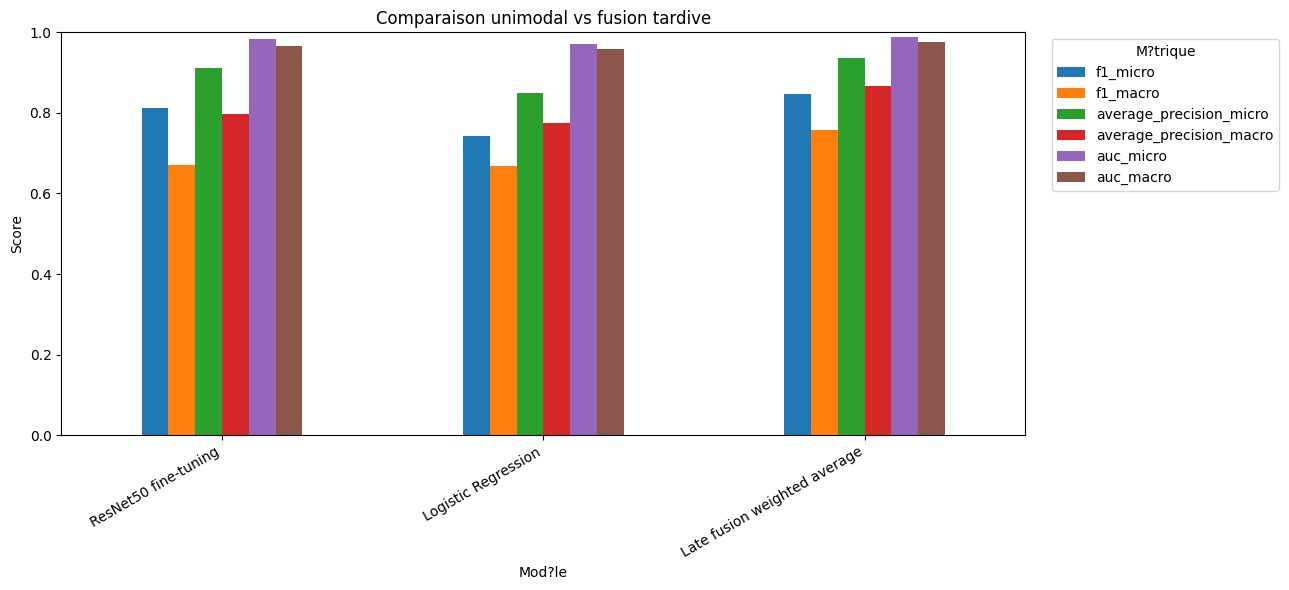

Rapport de classification - fusion tardive
              precision    recall  f1-score   support

     Label 1       0.97      0.94      0.95      3403
     Label 2       0.92      0.41      0.56       170
     Label 3       0.72      0.55      0.62       684
     Label 4       0.94      0.71      0.81       215
     Label 5       1.00      0.94      0.97       202
     Label 6       0.94      0.69      0.79       213
     Label 7       0.99      0.90      0.94       182
     Label 8       0.75      0.60      0.66       353
     Label 9       0.92      0.72      0.81       156
    Label 10       0.84      0.60      0.70       242
    Label 11       1.00      0.56      0.72        79
    Label 13       0.88      0.62      0.73        98
    Label 14       1.00      0.44      0.62        36
    Label 15       0.94      0.34      0.49       307
    Label 16       0.97      0.65      0.78       167
    Label 17       0.98      0.81      0.88       216
    Label 18       0.99      0.60     

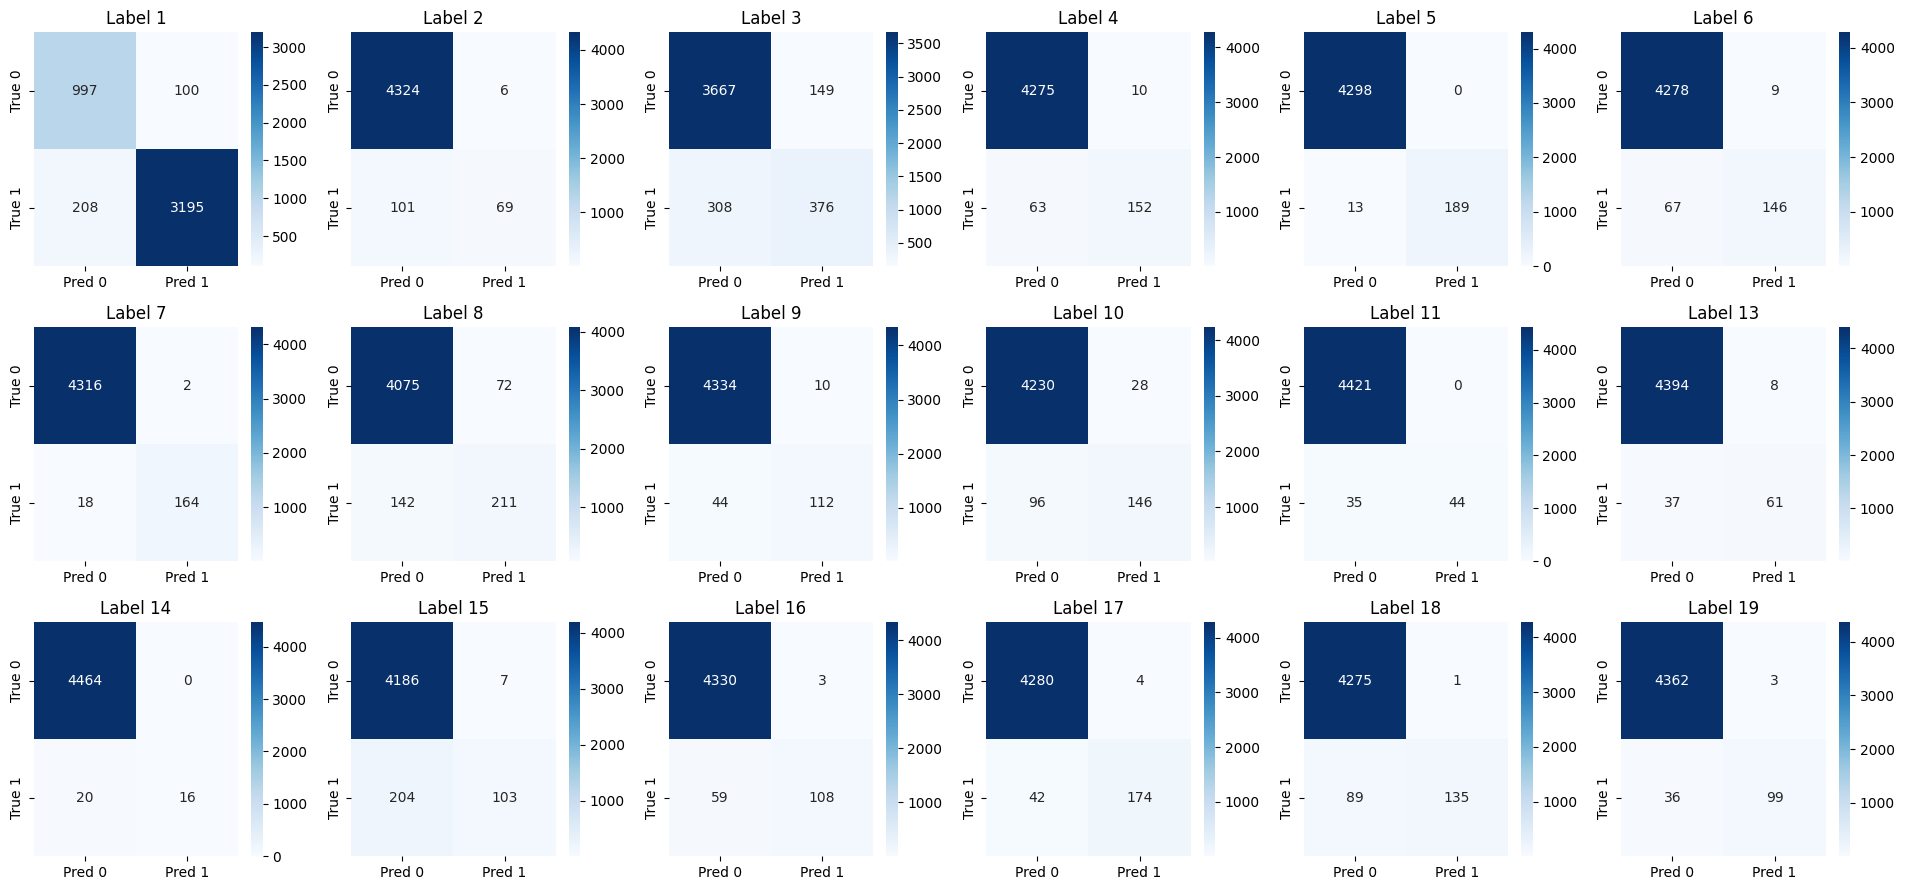

In [22]:
fusion_weight_rows = []

for image_weight in np.linspace(0.0, 1.0, 11):
    text_weight = 1.0 - image_weight
    fused_scores = (image_weight * image_test_scores) + (text_weight * text_test_scores)

    fusion_metrics, fusion_pred, _ = image_utils.evaluate_multilabel_predictions(
        y_test,
        fused_scores,
        threshold=0.5,
    )

    fusion_weight_rows.append({
        "model": f"Late fusion image={image_weight:.1f} text={text_weight:.1f}",
        "image_weight": round(float(image_weight), 1),
        "text_weight": round(float(text_weight), 1),
        **fusion_metrics,
    })

fusion_weight_results_df = pd.DataFrame(fusion_weight_rows)
fusion_weight_results_df = fusion_weight_results_df.sort_values(
    by="average_precision_macro",
    ascending=False,
).reset_index(drop=True)

best_fusion_row = fusion_weight_results_df.iloc[0]
best_image_weight = float(best_fusion_row["image_weight"])
best_text_weight = float(best_fusion_row["text_weight"])

late_fusion_test_scores = (best_image_weight * image_test_scores) + (best_text_weight * text_test_scores)
late_fusion_metrics, late_fusion_test_pred, _ = image_utils.evaluate_multilabel_predictions(
    y_test,
    late_fusion_test_scores,
    threshold=0.5,
)
late_fusion_metrics = {
    "model": "Late fusion weighted average",
    "image_weight": best_image_weight,
    "text_weight": best_text_weight,
    **late_fusion_metrics,
}

model_comparison_df = pd.concat([
    unimodal_test_results_df,
    pd.DataFrame([late_fusion_metrics]),
], ignore_index=True)

print("Meilleure pond?ration trouv?e :")
print(f"Image : {best_image_weight:.1f} | Texte : {best_text_weight:.1f}")

display(fusion_weight_results_df)
display(model_comparison_df)

plot_metrics = [
    "f1_micro",
    "f1_macro",
    "average_precision_micro",
    "average_precision_macro",
    "auc_micro",
    "auc_macro",
]

ax = model_comparison_df.set_index("model")[plot_metrics].plot(kind="bar", figsize=(13, 6))
ax.set_title("Comparaison unimodal vs fusion tardive")
ax.set_xlabel("Mod?le")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(title="M?trique", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print("Rapport de classification - fusion tardive")
print(classification_report(y_test, late_fusion_test_pred, target_names=class_names, zero_division=0))

image_utils.plot_multilabel_confusion_matrices(
    y_test,
    late_fusion_test_scores,
    class_names=classes,
    threshold=0.5,
    ncols=6,
)



## Note - Fusion tardive des pr?dictions

La fusion tardive consiste ? combiner les probabilit?s produites par les mod?les unimodaux, sans r?entra?ner directement leurs architectures internes. Ici, les scores du mod?le image et du mod?le texte sont combin?s par moyenne pond?r?e. Plusieurs pond?rations sont test?es afin d'identifier si la d?cision finale doit s'appuyer davantage sur l'image, sur le texte ou sur un ?quilibre entre les deux.

Cette approche est simple mais pertinente pour une premi?re fusion multimodale, surtout lorsque les deux mod?les n'ont pas la m?me nature technique : le mod?le image est un r?seau Keras, tandis que le mod?le texte retenu est un mod?le `sklearn` avec TF-IDF. Les deux sorties sont n?anmoins compatibles, car elles repr?sentent des probabilit?s par label.

Les r?sultats de la fusion sont compar?s aux mod?les unimodaux. Si la fusion am?liore certaines m?triques, cela sugg?re que les modalit?s apportent des informations compl?mentaires. Si elle n'am?liore pas les performances, cela peut indiquer qu'une modalit? domine fortement l'autre, ou qu'une fusion plus profonde par caract?ristiques serait n?cessaire.



## 10. Fusion par caractéristiques

La fusion par caractéristiques utilise les représentations internes des modèles image et texte.

Principe :

- retirer la dernière couche de classification du modèle image,
- retirer la dernière couche de classification du modèle texte,
- extraire les features image et texte,
- concaténer les deux représentations,
- ajouter une tête Dense multi-label avec sortie `sigmoid`.

Cette approche permet au modèle multimodal d'apprendre une représentation commune image + texte.


In [23]:
print("G?n?ration des pr?dictions image train / validation...")
image_train_scores = image_model.predict(train_image_ds, verbose=1)
image_val_scores = image_model.predict(val_image_ds, verbose=1)

print("G?n?ration des pr?dictions texte train / validation...")
text_train_scores = predict_text_probabilities(train_captions)
text_val_scores = predict_text_probabilities(val_captions)

image_train_scores = np.asarray(image_train_scores)
image_val_scores = np.asarray(image_val_scores)
text_train_scores = np.asarray(text_train_scores)
text_val_scores = np.asarray(text_val_scores)

X_train_fusion = np.concatenate([image_train_scores, text_train_scores], axis=1)
X_val_fusion = np.concatenate([image_val_scores, text_val_scores], axis=1)
X_test_fusion = np.concatenate([image_test_scores, text_test_scores], axis=1)

fusion_feature_names = (
    [f"image_score_label_{label}" for label in classes]
    + [f"text_score_label_{label}" for label in classes]
)

fusion_feature_summary_df = pd.DataFrame([
    {"split": "train", "image_scores": image_train_scores.shape, "text_scores": text_train_scores.shape, "fusion_features": X_train_fusion.shape, "target": y_train.shape},
    {"split": "validation", "image_scores": image_val_scores.shape, "text_scores": text_val_scores.shape, "fusion_features": X_val_fusion.shape, "target": y_val.shape},
    {"split": "test", "image_scores": image_test_scores.shape, "text_scores": text_test_scores.shape, "fusion_features": X_test_fusion.shape, "target": y_test.shape},
])

print("Nombre de caract?ristiques fusionn?es :", X_train_fusion.shape[1])
display(fusion_feature_summary_df)

display(pd.DataFrame(X_train_fusion[:5], columns=fusion_feature_names))



G?n?ration des pr?dictions image train / validation...
657/657 ━━━━━━━━━━━━━━━━━━━━ 768s 1s/step
141/141 ━━━━━━━━━━━━━━━━━━━━ 159s 1s/step
G?n?ration des pr?dictions texte train / validation...
Nombre de caract?ristiques fusionn?es : 36


,split,image_scores,text_scores,fusion_features,target
0,train,"(21000, 18)","(21000, 18)","(21000, 36)","(21000, 18)"
1,validation,"(4500, 18)","(4500, 18)","(4500, 36)","(4500, 18)"
2,test,"(4500, 18)","(4500, 18)","(4500, 36)","(4500, 18)"


,image_score_label_1,image_score_label_2,image_score_label_3,image_score_label_4,image_score_label_5,image_score_label_6,image_score_label_7,image_score_label_8,image_score_label_9,image_score_label_10,...,text_score_label_9,text_score_label_10,text_score_label_11,text_score_label_13,text_score_label_14,text_score_label_15,text_score_label_16,text_score_label_17,text_score_label_18,text_score_label_19
0,0.977432,0.068428,0.194274,0.029431,0.000210,0.002784,3.159703e-02,0.038805,0.000406,0.028329,...,0.248906,0.681134,0.152877,0.290942,0.095863,0.698305,0.079693,0.021449,0.092534,0.017648
1,0.399718,0.004953,0.250990,0.002430,0.964289,0.017798,9.640714e-05,0.137400,0.019104,0.008551,...,0.303675,0.056774,0.055853,0.036746,0.012989,0.035222,0.036340,0.048209,0.061540,0.017911
2,0.471027,0.001783,0.011123,0.000226,0.000899,0.003134,1.016582e-03,0.001990,0.682106,0.000632,...,0.812071,0.103467,0.073843,0.020187,0.013176,0.110555,0.243282,0.050934,0.185390,0.019831
3,0.990983,0.038809,0.170140,0.006193,0.058509,0.013880,8.303774e-03,0.113146,0.022119,0.010410,...,0.029482,0.041572,0.036581,0.011180,0.014652,0.210531,0.110470,0.032648,0.090849,0.074957
4,0.997147,0.001910,0.007715,0.000161,0.000022,0.000013,6.048990e-07,0.001216,0.004541,0.000042,...,0.317387,0.015009,0.007083,0.011011,0.010323,0.055185,0.362834,0.014940,0.088775,0.041376


## Note - Fusion par caract?ristiques

Cette ?tape construit une repr?sentation commune ? partir des sorties des deux mod?les unimodaux. Pour chaque exemple, le mod?le image produit 18 scores, un par label, et le mod?le texte produit ?galement 18 scores. Ces deux vecteurs sont concat?n?s pour former un vecteur de 36 caract?ristiques.

Cette approche correspond ? une fusion par caract?ristiques de haut niveau : on ne fusionne pas les pixels et les mots bruts, mais les informations d?j? apprises par les mod?les sp?cialis?s. Elle est adapt?e ici car les mod?les unimodaux n'ont pas la m?me nature technique : le mod?le image est un r?seau de neurones Keras, tandis que le mod?le texte retenu est un mod?le `sklearn` bas? sur TF-IDF.

Le r?sultat de cette ?tape est donc `X_train_fusion`, `X_val_fusion` et `X_test_fusion`, qui seront utilis?s pour entra?ner un classifieur multimodal final.



## 11. Entraînement du modèle multimodal

Cette partie entraîne la tête de fusion multimodale.

Deux stratégies peuvent être comparées :

- branches image et texte gelées, seule la tête de fusion est entraînée,
- fine-tuning léger d'une partie des branches si les performances le justifient.

La loss utilisée doit être `binary_crossentropy`, car une image peut appartenir à plusieurs labels.


Model: "multimodal_feature_fusion"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fusion_dense_1 (Dense)          │ (None, 64)             │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fusion_batch_norm_1             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fusion_dropout_1 (Dropout)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fusion_dense_2 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fusion_dropout_2 (Dropout)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multilabel_output (Dense)       │ (None, 18)             │           594 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,298 (20.70 KB)

 Trainable params: 5,170 (20.20 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - auc: 0.7379 - binary_accuracy: 0.8762 - loss: 0.2976 - val_auc: 0.8935 - val_binary_accuracy: 0.9544 - val_loss: 0.2042 - learning_rate: 0.0010
Epoch 2/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - auc: 0.8997 - binary_accuracy: 0.9570 - loss: 0.1262 - val_auc: 0.9424 - val_binary_accuracy: 0.9685 - val_loss: 0.1085 - learning_rate: 0.0010
Epoch 3/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - auc: 0.9269 - binary_accuracy: 0.9644 - loss: 0.1046 - val_auc: 0.9583 - val_binary_accuracy: 0.9737 - val_loss: 0.0810 - learning_rate: 0.0010
Epoch 4/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.9356 - binary_accuracy: 0.9675 - loss: 0.0956 - val_auc: 0.9614 - val_binary_accuracy: 0.9750 - val_loss: 0.0740 - learning_rate: 0.0010
Epoch 5/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - auc: 0.9434 - binary_accuracy: 0.9695 - loss: 0.0895 - val_auc: 0.9633 - val_binary_accuracy: 0.9757 - val_loss: 0.0708 - learning_rate: 0.0010
Epoch 6/30

,auc,binary_accuracy,loss,val_auc,val_binary_accuracy,val_loss,learning_rate
25,0.959253,0.974743,0.073517,0.970787,0.977642,0.063032,0.00050
26,0.960018,0.974910,0.072998,0.970703,0.977741,0.062981,0.00025
27,0.959974,0.975016,0.072966,0.971273,0.977679,0.062804,0.00025
28,0.961013,0.974733,0.072928,0.970602,0.977679,0.062770,0.00025
29,0.959132,0.975148,0.073200,0.970460,0.977716,0.062767,0.00025


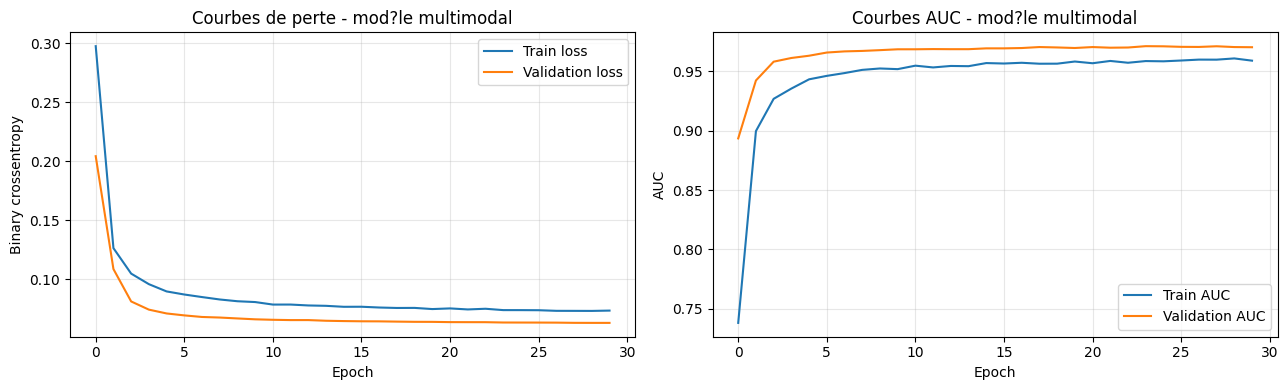

In [24]:
multimodal_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_fusion.shape[1],), name="fusion_input"),
    tf.keras.layers.Dense(64, activation="relu", name="fusion_dense_1"),
    tf.keras.layers.BatchNormalization(name="fusion_batch_norm_1"),
    tf.keras.layers.Dropout(0.30, name="fusion_dropout_1"),
    tf.keras.layers.Dense(32, activation="relu", name="fusion_dense_2"),
    tf.keras.layers.Dropout(0.20, name="fusion_dropout_2"),
    tf.keras.layers.Dense(NUM_CLASSES, activation="sigmoid", name="multilabel_output"),
], name="multimodal_feature_fusion")

multimodal_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="binary_accuracy"),
        tf.keras.metrics.AUC(name="auc", multi_label=True),
    ],
)

multimodal_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-5,
    ),
]

EPOCHS_MULTIMODAL = 30
BATCH_SIZE_MULTIMODAL = 128

multimodal_model.summary()

history_multimodal = multimodal_model.fit(
    X_train_fusion,
    y_train,
    validation_data=(X_val_fusion, y_val),
    epochs=EPOCHS_MULTIMODAL,
    batch_size=BATCH_SIZE_MULTIMODAL,
    callbacks=multimodal_callbacks,
    verbose=1,
)

history_multimodal_df = pd.DataFrame(history_multimodal.history)
display(history_multimodal_df.tail())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history_multimodal_df["loss"], label="Train loss")
axes[0].plot(history_multimodal_df["val_loss"], label="Validation loss")
axes[0].set_title("Courbes de perte - mod?le multimodal")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary crossentropy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_multimodal_df["auc"], label="Train AUC")
axes[1].plot(history_multimodal_df["val_auc"], label="Validation AUC")
axes[1].set_title("Courbes AUC - mod?le multimodal")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("AUC")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()



## Note - Entra?nement du mod?le multimodal

Le mod?le multimodal entra?n? ici est une petite t?te dense qui re?oit en entr?e les caract?ristiques fusionn?es produites ? l'?tape pr?c?dente. Il apprend donc ? pond?rer et combiner les informations venant de l'image et du texte pour pr?dire les labels finaux.

La sortie utilise une activation `sigmoid`, car le probl?me est multi-label : chaque label est pr?dit ind?pendamment avec une probabilit? entre 0 et 1. La fonction de perte est `binary_crossentropy`, adapt?e ? ce type de classification.

Des callbacks sont utilis?s pour limiter le sur-apprentissage : `EarlyStopping` restaure les meilleurs poids observ?s sur la validation, et `ReduceLROnPlateau` diminue le taux d'apprentissage si la validation n'am?liore plus. Les courbes de perte et d'AUC permettent ensuite de diagnostiquer si le mod?le apprend correctement ou s'il sur-apprend.



## 12. Comparaison finale

Cette partie doit comparer toutes les approches :

- `image_only`,
- `text_only`,
- `late_fusion`,
- `feature_fusion`.

La comparaison doit être présentée sous forme de tableau avec les métriques multi-label retenues. Le choix du modèle final doit être justifié à partir des résultats.


36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Meilleur mod?le selon average_precision_macro : Late fusion weighted average


,model,threshold,f1_micro,f1_macro,average_precision_micro,average_precision_macro,auc_micro,auc_macro,image_weight,text_weight
0,Late fusion weighted average,0.5,0.846545,0.756703,0.936179,0.865945,0.988471,0.975818,0.6,0.4
1,Feature fusion dense model,0.5,0.857512,0.788231,0.938475,0.861295,0.988054,0.974668,NaN,NaN
2,ResNet50 fine-tuning,0.5,0.812759,0.671161,0.912202,0.796886,0.984019,0.966154,NaN,NaN
3,Logistic Regression,0.5,0.741572,0.666971,0.848871,0.773985,0.970164,0.957750,NaN,NaN


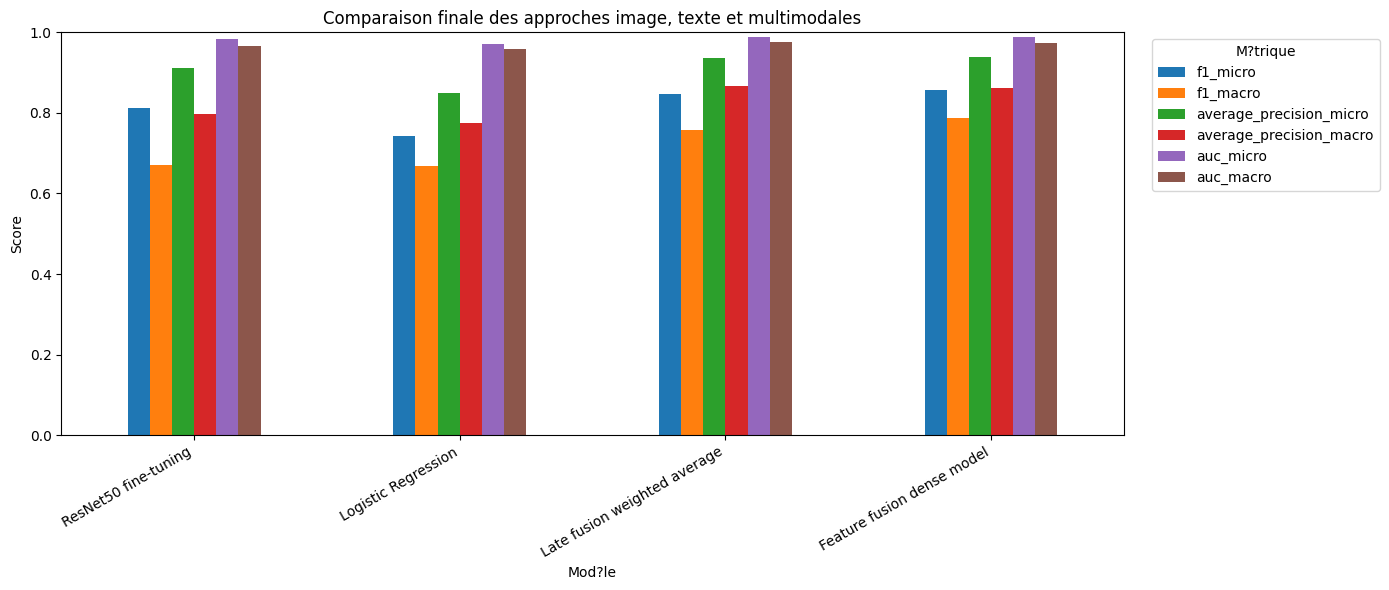

Rapport de classification - mod?le multimodal par caract?ristiques
              precision    recall  f1-score   support

     Label 1       0.97      0.94      0.95      3403
     Label 2       0.91      0.44      0.59       170
     Label 3       0.74      0.56      0.64       684
     Label 4       0.98      0.74      0.84       215
     Label 5       0.99      0.97      0.98       202
     Label 6       0.94      0.69      0.80       213
     Label 7       0.95      0.96      0.96       182
     Label 8       0.84      0.55      0.66       353
     Label 9       0.89      0.71      0.79       156
    Label 10       0.84      0.54      0.65       242
    Label 11       0.98      0.68      0.81        79
    Label 13       0.89      0.56      0.69        98
    Label 14       0.93      0.69      0.79        36
    Label 15       0.82      0.41      0.55       307
    Label 16       0.92      0.69      0.79       167
    Label 17       0.96      0.89      0.93       216
    Label 18  

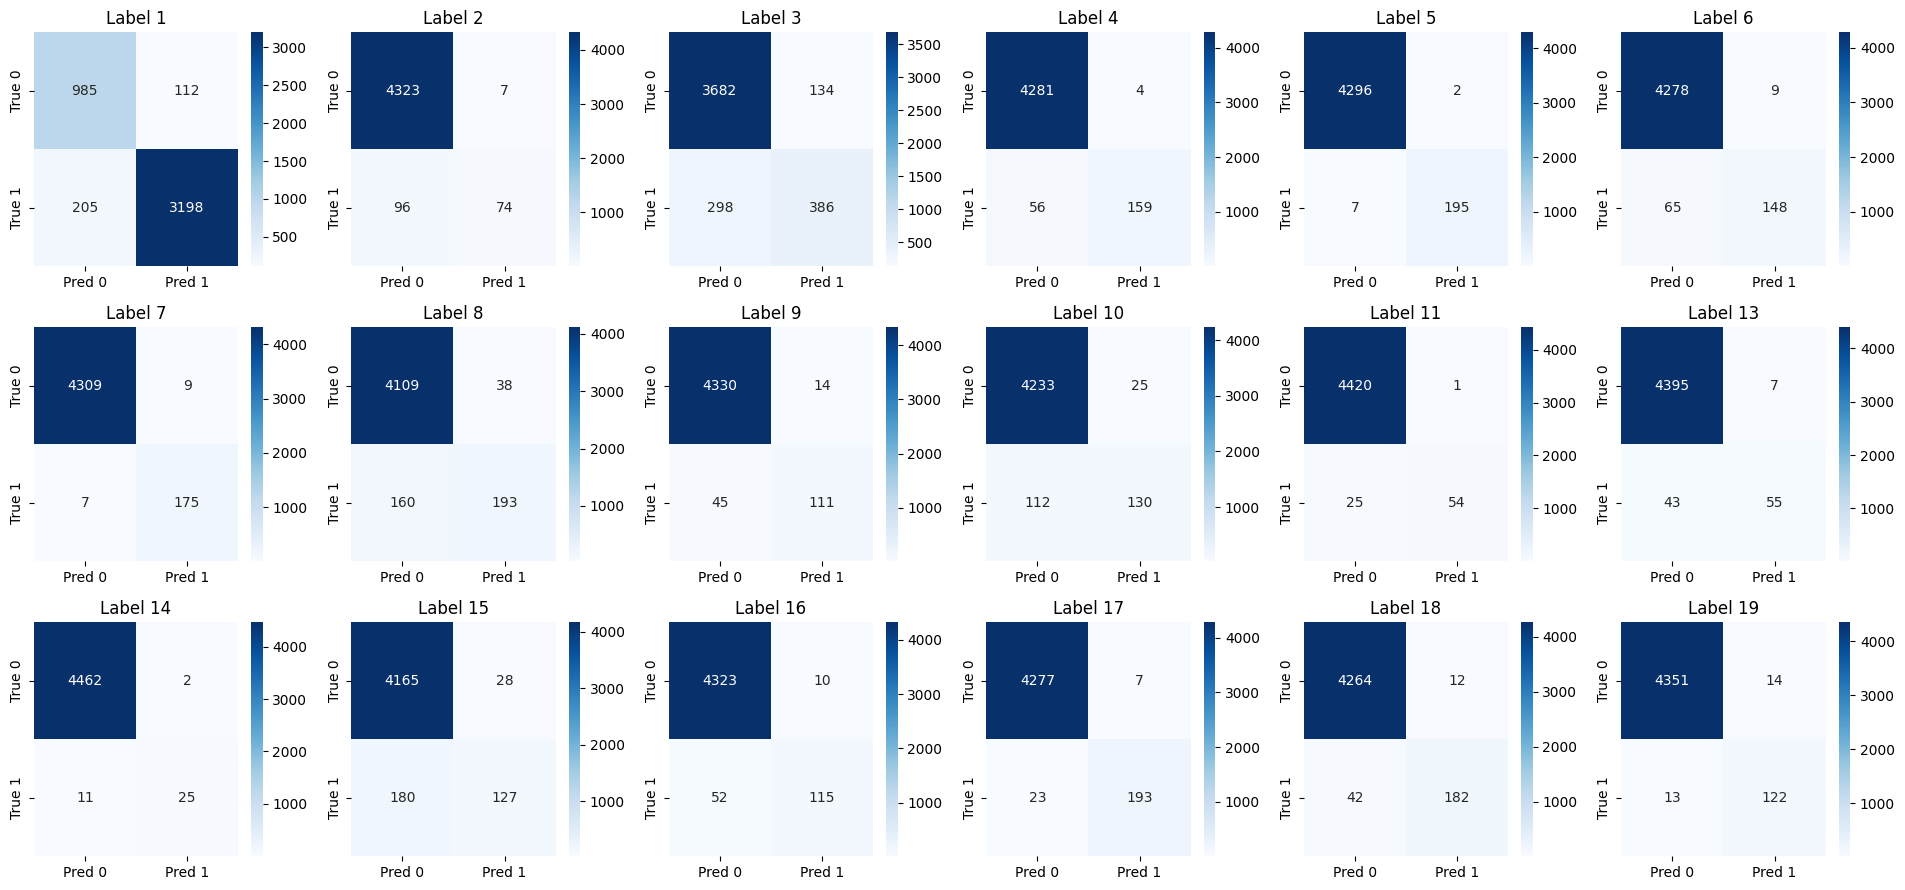

In [25]:
MULTIMODAL_THRESHOLD = 0.5

multimodal_test_scores = multimodal_model.predict(
    X_test_fusion,
    batch_size=BATCH_SIZE_MULTIMODAL,
    verbose=1,
)

multimodal_metrics, multimodal_test_pred, _ = image_utils.evaluate_multilabel_predictions(
    y_test,
    multimodal_test_scores,
    threshold=MULTIMODAL_THRESHOLD,
)

multimodal_metrics = {
    "model": "Feature fusion dense model",
    "threshold": MULTIMODAL_THRESHOLD,
    **{key: value for key, value in multimodal_metrics.items() if key != "threshold"},
}

final_comparison_df = pd.concat([
    model_comparison_df,
    pd.DataFrame([multimodal_metrics]),
], ignore_index=True)

metric_columns = [
    "f1_micro",
    "f1_macro",
    "average_precision_micro",
    "average_precision_macro",
    "auc_micro",
    "auc_macro",
]

final_comparison_sorted_df = final_comparison_df.sort_values(
    by="average_precision_macro",
    ascending=False,
).reset_index(drop=True)

best_final_model_name = final_comparison_sorted_df.iloc[0]["model"]

print("Meilleur mod?le selon average_precision_macro :", best_final_model_name)
display(final_comparison_sorted_df)

ax = final_comparison_df.set_index("model")[metric_columns].plot(kind="bar", figsize=(14, 6))
ax.set_title("Comparaison finale des approches image, texte et multimodales")
ax.set_xlabel("Mod?le")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(title="M?trique", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print("Rapport de classification - mod?le multimodal par caract?ristiques")
print(classification_report(y_test, multimodal_test_pred, target_names=class_names, zero_division=0))

image_utils.plot_multilabel_confusion_matrices(
    y_test,
    multimodal_test_scores,
    class_names=classes,
    threshold=MULTIMODAL_THRESHOLD,
    ncols=6,
)



## Note - Comparaison finale

Cette ?tape compare les mod?les unimodaux, la fusion tardive et le mod?le de fusion par caract?ristiques. Le crit?re principal retenu est l'Average Precision macro, car il tient mieux compte du d?s?quilibre des labels que l'accuracy globale.

Le tableau final permet d'identifier si la fusion am?liore r?ellement les performances. Une am?lioration indique que l'image et le texte apportent des informations compl?mentaires. ? l'inverse, si le meilleur mod?le reste unimodal, cela signifie que la fusion propos?e n'exploite pas encore suffisamment les deux sources ou qu'une modalit? domine l'autre.

La matrice de confusion multi-label et le rapport de classification permettent d'analyser plus finement les labels bien reconnus et ceux qui restent difficiles.



## 13. Analyse qualitative des résultats

Cette partie doit afficher quelques exemples de test avec :

- l'image,
- la caption,
- les vrais labels,
- les prédictions image,
- les prédictions texte,
- les prédictions multimodales.

L'objectif est d'identifier les cas où l'image aide, les cas où le texte aide, les cas où la fusion améliore la prédiction et les cas où elle échoue.


,ImageID,Caption,true_labels,predicted_labels,top_scores,error_count
0,11686.jpg,Two dogs sit chained to a pole on the sidewalk.,"[1, 3, 4, 11, 18]","[3, 8]","[3 (0.839), 8 (0.527), 11 (0.442), 1 (0.417), ...",5
1,13748.jpg,A narrow road surrounded by tall buildings and...,"[2, 15]","[1, 3, 10]","[1 (0.967), 3 (0.765), 10 (0.600), 2 (0.366), ...",5
2,28745.jpg,A city street with lots of cars parked on it.,"[3, 8, 11, 13]","[1, 3, 10]","[3 (0.839), 10 (0.721), 1 (0.686), 8 (0.453), ...",5
3,4421.jpg,A stone pavilion with a clock on the top of it.,"[1, 2, 3]",[15],"[15 (0.814), 1 (0.418), 3 (0.123), 16 (0.069),...",4
4,17390.jpg,A white bus next to a train station at night.,"[1, 2, 6]","[1, 7, 15]","[7 (0.946), 1 (0.752), 15 (0.586), 6 (0.148), ...",4
5,8966.jpg,Four birds sitting on top of a wooden bench.,"[1, 3, 6, 8, 15, 16]","[3, 15]","[15 (0.896), 3 (0.553), 9 (0.481), 1 (0.292), ...",4
6,24344.jpg,A cow sitting in a dirt road in front of dilap...,"[1, 2]","[3, 8]","[8 (0.685), 3 (0.532), 4 (0.410), 1 (0.358), 1...",4
7,3778.jpg,A person that is looking at something down the...,"[1, 8, 10, 11]","[1, 3]","[1 (0.999), 3 (0.759), 10 (0.350), 8 (0.274), ...",4


,label,tp,fp,fn,tn,precision,recall,f1
13,15,127,28,180,4165,0.819,0.414,0.550
1,2,74,7,96,4323,0.914,0.435,0.590
2,3,386,134,298,3682,0.742,0.564,0.641
9,10,130,25,112,4233,0.839,0.537,0.655
7,8,193,38,160,4109,0.835,0.547,0.661
11,13,55,7,43,4395,0.887,0.561,0.688
14,16,115,10,52,4323,0.920,0.689,0.788
8,9,111,14,45,4330,0.888,0.712,0.790
12,14,25,2,11,4462,0.926,0.694,0.794
5,6,148,9,65,4278,0.943,0.695,0.800


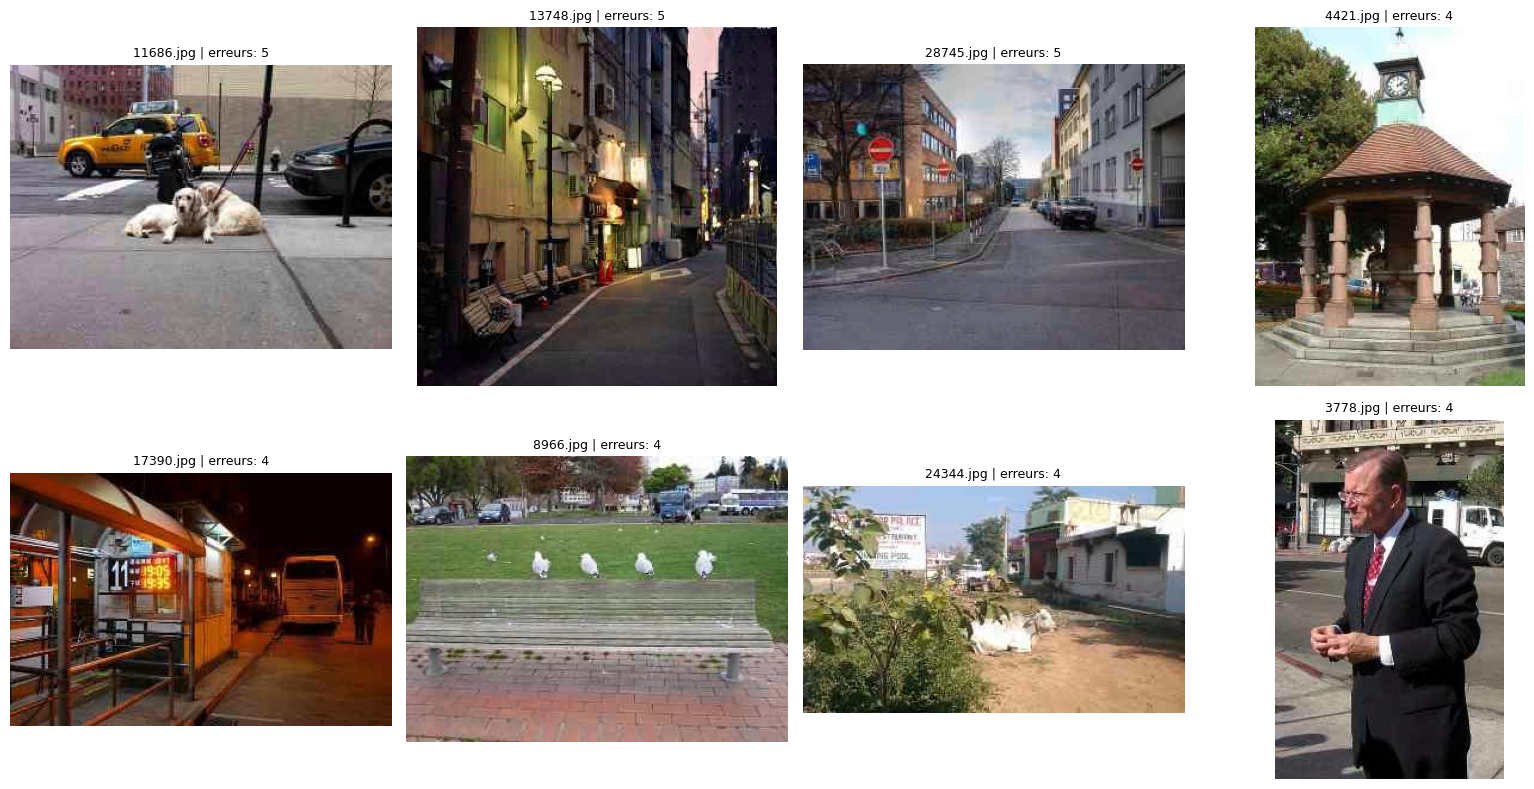

In [26]:
multimodal_error_counts = np.abs(y_test - multimodal_test_pred).sum(axis=1)
worst_multimodal_indices = np.argsort(multimodal_error_counts)[::-1][:8]

qualitative_rows = []
for index in worst_multimodal_indices:
    qualitative_rows.append({
        "ImageID": test_df.loc[index, "ImageID"],
        "Caption": test_df.loc[index, "Caption"],
        "true_labels": text_utils.active_labels_from_binary(y_test[index], classes),
        "predicted_labels": text_utils.active_labels_from_binary(multimodal_test_pred[index], classes),
        "top_scores": text_utils.top_label_scores(multimodal_test_scores[index], classes, top_k=5),
        "error_count": int(multimodal_error_counts[index]),
    })

worst_multimodal_errors_df = pd.DataFrame(qualitative_rows)
display(worst_multimodal_errors_df)

label_error_multimodal_df = text_utils.label_error_summary(
    y_test,
    multimodal_test_pred,
    classes,
).sort_values(by="f1")

display(label_error_multimodal_df)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.reshape(-1)

for ax, index in zip(axes, worst_multimodal_indices):
    image = plt.imread(test_df.loc[index, "image_path"])
    ax.imshow(image)
    ax.axis("off")
    ax.set_title(
        f"{test_df.loc[index, 'ImageID']} | erreurs: {int(multimodal_error_counts[index])}",
        fontsize=9,
    )

for ax in axes[len(worst_multimodal_indices):]:
    ax.axis("off")

plt.tight_layout()
plt.show()



## Note - Analyse qualitative des r?sultats

Cette ?tape examine les exemples o? le mod?le multimodal commet le plus d'erreurs. Pour chaque image, on affiche les vrais labels, les labels pr?dits, les scores les plus ?lev?s et le nombre total d'erreurs. Cela permet de comprendre si les erreurs viennent plut?t d'oublis de labels pr?sents ou de labels pr?dits ? tort.

Le tableau par label met en ?vidence les classes les plus difficiles. Les labels rares ont souvent des scores F1 plus faibles, car le mod?le dispose de moins d'exemples pour apprendre leurs caract?ristiques.

Ces observations permettent de proposer des pistes d'am?lioration : ajuster les seuils par label, mieux g?rer le d?s?quilibre des classes, enrichir les donn?es des labels rares ou utiliser une fusion plus profonde entre les repr?sentations image et texte.



## 14. Sauvegarde du modèle multimodal

Le modèle multimodal retenu doit être sauvegardé dans `model/registry/`.

Les métadonnées associées peuvent inclure :

- type de fusion utilisée,
- métriques obtenues,
- date d'entraînement,
- modèles unimodaux utilisés,
- paramètres principaux du preprocessing.


In [27]:
REGISTRY_DIR.mkdir(parents=True, exist_ok=True)

multimodal_model.save(MULTIMODAL_MODEL_PATH)

multimodal_metadata = {
    "model_name": "Feature fusion dense model",
    "model_type": "keras_feature_fusion",
    "model_path": str(MULTIMODAL_MODEL_PATH),
    "fusion_type": "concatenation_of_unimodal_probabilities",
    "image_model_name": image_metadata.get("model_name"),
    "image_model_path": str(IMAGE_MODEL_PATH),
    "text_model_name": text_metadata.get("model_name"),
    "text_model_type": TEXT_MODEL_TYPE,
    "text_model_path": str(TEXT_MODEL_PATH),
    "classes": [str(label) for label in classes],
    "threshold": MULTIMODAL_THRESHOLD,
    "input_features": fusion_feature_names,
    "num_input_features": int(X_train_fusion.shape[1]),
    "metrics": {
        key: float(value) if isinstance(value, (np.floating, float, int, np.integer)) else value
        for key, value in multimodal_metrics.items()
    },
    "late_fusion_best_weights": {
        "image_weight": float(best_image_weight),
        "text_weight": float(best_text_weight),
    },
}

MULTIMODAL_METADATA_PATH.write_text(
    json.dumps(multimodal_metadata, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

saved_multimodal_artifacts_df = pd.DataFrame([
    {"artifact": "multimodal_model", "path": str(MULTIMODAL_MODEL_PATH), "exists": MULTIMODAL_MODEL_PATH.exists()},
    {"artifact": "multimodal_metadata", "path": str(MULTIMODAL_METADATA_PATH), "exists": MULTIMODAL_METADATA_PATH.exists()},
])

display(saved_multimodal_artifacts_df)
print("Mod?le multimodal sauvegard? dans :", MULTIMODAL_MODEL_PATH)
print("M?tadonn?es sauvegard?es dans :", MULTIMODAL_METADATA_PATH)



,artifact,path,exists
0,multimodal_model,C:\Users\mupps\Documents\Tp_bihar-2025-2026\mo...,True
1,multimodal_metadata,C:\Users\mupps\Documents\Tp_bihar-2025-2026\mo...,True


Mod?le multimodal sauvegard? dans : C:\Users\mupps\Documents\Tp_bihar-2025-2026\model\registry\multimodal_model.keras
M?tadonn?es sauvegard?es dans : C:\Users\mupps\Documents\Tp_bihar-2025-2026\model\registry\multimodal_model_metadata.json


## Note - Sauvegarde du mod?le multimodal

Cette ?tape sauvegarde le mod?le multimodal final dans le registre du projet. Le mod?le est enregistr? au format Keras afin de pouvoir ?tre recharg? plus tard pour de nouvelles pr?dictions ou pour une d?monstration.

Un fichier de m?tadonn?es est ?galement cr??. Il documente le type de fusion utilis?e, les mod?les unimodaux utilis?s, les classes pr?dites, le seuil de d?cision, les m?triques obtenues et la structure des caract?ristiques d'entr?e. Cette information est importante pour la reproductibilit? et pour expliquer clairement le pipeline lors de la soutenance.



## 15. Conclusion

Cette conclusion doit résumer :

- l'intérêt de la fusion multimodale,
- la comparaison entre image seule, texte seul et image + texte,
- le modèle final retenu,
- les limites observées,
- les pistes d'amélioration.


## Note - Conclusion

Ce notebook met en place une approche multimodale compl?te ? partir des mod?les image et texte entra?n?s s?par?ment. Les deux modalit?s sont d'abord ?valu?es ind?pendamment, puis combin?es avec deux strat?gies : une fusion tardive des probabilit?s et une fusion par caract?ristiques suivie d'un petit r?seau dense.

La d?marche respecte l'objectif du sujet : comparer les performances unimodales et multimodales, puis justifier le choix du mod?le final ? partir de m?triques adapt?es ? la classification multi-label. Les r?sultats doivent ?tre interpr?t?s avec prudence, car le dataset est fortement d?s?quilibr? et certains labels sont beaucoup plus rares que d'autres.

Les principales pistes d'am?lioration seraient d'optimiser un seuil diff?rent par label, d'utiliser une m?thode de pond?ration des classes, d'entra?ner une vraie architecture jointe image + texte avec des embeddings internes, ou de remplacer les captions TF-IDF par un encodeur de texte plus riche.

